In [3]:
%pip install --quiet pandas numpy scikit-learn matplotlib seaborn nltk
import sys
print(sys.executable)


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import nltk
nltk.download("punkt")

In [1]:

import pandas as pd
import numpy as np

# Preprocesado de texto
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Dividir datos y pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Modelos
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sofia\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [2]:
from google.colab import files

# Esto abre una ventana para subir tu archivo Excel
uploaded = files.upload()

# Aquí cambiamos el nombre del archivo por el que subiste (ajústalo si es necesario)
nombre_archivo = list(uploaded.keys())[0]

# Cargamos el archivo Excel (requiere 'openpyxl' que ya instalamos antes)
df = pd.read_excel(nombre_archivo)

# Mostramos las primeras filas para revisar que se cargó correctamente
df.head()


ModuleNotFoundError: No module named 'google'

Columnas disponibles:
Index(['Law', 'Article', 'Spanish text', 'Relevance', 'Interpretability',
       'Completeness', 'Differential Regime', 'Discretionality'],
      dtype='object')

🔹 Análisis de la categoría: Relevance
Relevance
0    97
1    72
Name: count, dtype: int64
Porcentaje por clase:
Relevance
0    57.4
1    42.6
Name: proportion, dtype: float64

🔹 Análisis de la categoría: Interpretability
Interpretability
1    81
3    52
2    36
Name: count, dtype: int64
Porcentaje por clase:
Interpretability
1    47.93
3    30.77
2    21.30
Name: proportion, dtype: float64

🔹 Análisis de la categoría: Completeness
Completeness
0    122
1     47
Name: count, dtype: int64
Porcentaje por clase:
Completeness
0    72.19
1    27.81
Name: proportion, dtype: float64

🔹 Análisis de la categoría: Differential Regime
Differential Regime
0    109
1     60
Name: count, dtype: int64
Porcentaje por clase:
Differential Regime
0    64.5
1    35.5
Name: proportion, dtype: float64

🔹 Análisis de la categor

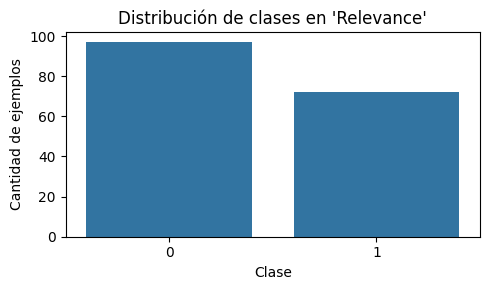

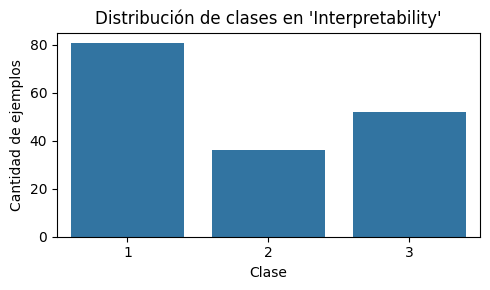

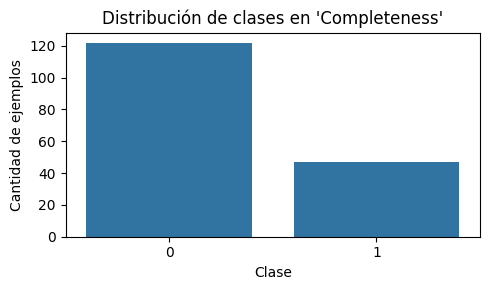

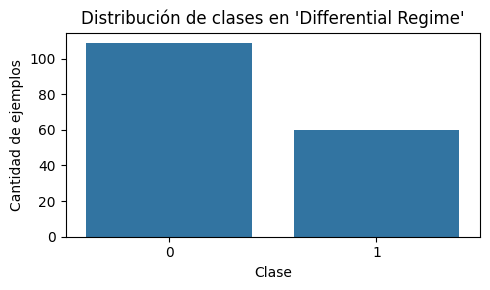

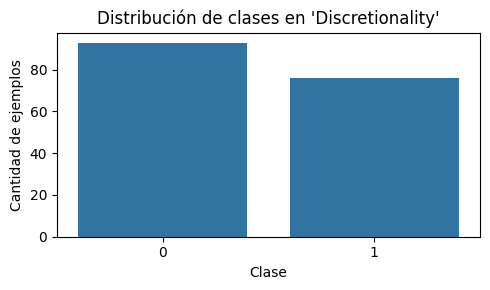

📌 Estadísticas de longitud del texto legal (número de palabras):
count    169.000000
mean      81.733728
std       61.930309
min        6.000000
25%       41.000000
50%       64.000000
75%       99.000000
max      374.000000
Name: n_palabras, dtype: float64


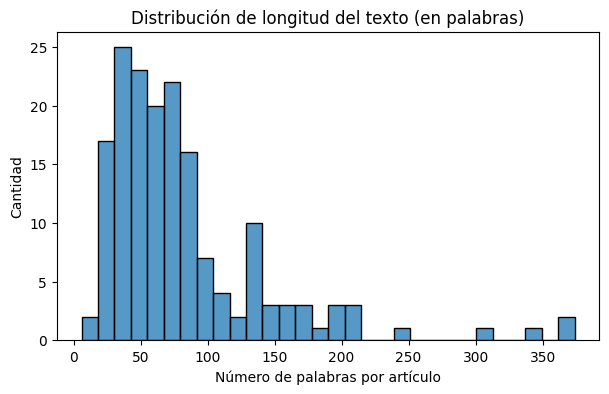

In [ ]:
# Vemos todas las columnas para asegurarnos de tener las categorías correctas
print("Columnas disponibles:")
print(df.columns)

# Lista de columnas que representan categorías (ajústala si el nombre de alguna varía)
categorias = ['Relevance', 'Interpretability', 'Completeness', 'Differential Regime', 'Discretionality']

# Revisión de valores únicos por categoría
for cat in categorias:
    print(f"\n🔹 Análisis de la categoría: {cat}")
    print(df[cat].value_counts())
    print("Porcentaje por clase:")
    print(round(df[cat].value_counts(normalize=True) * 100, 2))

for cat in categorias:
    plt.figure(figsize=(5,3))
    sns.countplot(x=cat, data=df)
    plt.title(f"Distribución de clases en '{cat}'")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de ejemplos")
    plt.tight_layout()
    plt.show()

  # Agregamos una columna con el número de palabras de cada artículo
df['n_palabras'] = df['Spanish text'].astype(str).str.split().apply(len)

# Estadísticas generales
print("📌 Estadísticas de longitud del texto legal (número de palabras):")
print(df['n_palabras'].describe())

# Histograma de distribución de longitud
plt.figure(figsize=(7,4))
sns.histplot(df['n_palabras'], bins=30)
plt.title("Distribución de longitud del texto (en palabras)")
plt.xlabel("Número de palabras por artículo")
plt.ylabel("Cantidad")
plt.show()


In [ ]:
# Obtenemos la lista de palabras vacías (stopwords) en español
stop_es = set(stopwords.words('spanish'))

# Definimos una función para limpiar cada texto
def limpiar_texto(texto):
    texto = str(texto).lower()                         # pasamos todo a minúsculas
    texto = re.sub(r"http\S+", "", texto)              # quitamos URLs
    texto = re.sub(r"[^a-záéíóúüñ\s]", "", texto)       # eliminamos signos y símbolos
    palabras = texto.split()                           # separamos por palabras
    palabras = [w for w in palabras if w not in stop_es and len(w) > 2]  # quitamos palabras vacías y muy cortas
    return " ".join(palabras)                          # juntamos nuevamente

# Aplicamos la limpieza al texto legal
df['texto_limpio'] = df['Spanish text'].apply(limpiar_texto)

# Mostramos un ejemplo antes y después
df[['Spanish text', 'texto_limpio']].head()


,Spanish text,texto_limpio
0,Crease la Zona Franca Industrial y Comercial d...,crease zona franca industrial comercial barran...
1,El Gobierno podrá aceptar para la explotación ...,gobierno podrá aceptar explotación zonas franc...
2,Decláranse de utilidad pública los terrenos o ...,decláranse utilidad pública terrenos áreas ind...
3,La Zona Franca Industrial y Comercial de Barra...,zona franca industrial comercial barranquilla ...
4,Las Zonas Francas industriales y comerciales t...,zonas francas industriales comerciales objeto ...


In [ ]:

# Categorías a procesar
categorias = ['Relevance', 'Interpretability', 'Completeness', 'Differential Regime', 'Discretionality']

# Almacenamos resultados para análisis posterior
resultados_modelo = []

print("🚀 Entrenando modelos por categoría...")

for cat in categorias:
    print("="*80)
    print(f"📂 Procesando: {cat}")

    datos = df[['texto_limpio', cat]].dropna()
    X = datos['texto_limpio']
    y = datos[cat]

    # Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Pipeline con TF-IDF y modelo
    pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=3, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))  # 🟢 balance activado
])

    # Entrenar
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Guardar resultados necesarios
    resultados_modelo.append({
        'categoria': cat,
        'modelo': pipeline,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'etiquetas': sorted(y.unique()),
        'reporte': classification_report(y_test, y_pred, output_dict=True),
        'accuracy': accuracy_score(y_test, y_pred)
    })

    print(f"✅ Modelo para {cat} entrenado con éxito.")


🚀 Entrenando modelos por categoría...
📂 Procesando: Relevance
✅ Modelo para Relevance entrenado con éxito.
📂 Procesando: Interpretability
✅ Modelo para Interpretability entrenado con éxito.
📂 Procesando: Completeness
✅ Modelo para Completeness entrenado con éxito.
📂 Procesando: Differential Regime
✅ Modelo para Differential Regime entrenado con éxito.
📂 Procesando: Discretionality
✅ Modelo para Discretionality entrenado con éxito.


📊 Iniciando análisis de resultados...
📈 Evaluando categoría: Relevance


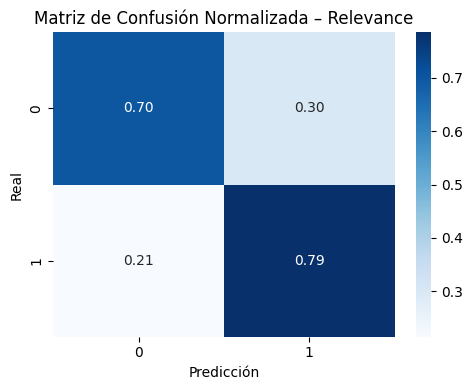

,precision,recall,f1-score
0,0.824,0.700,0.757
1,0.647,0.786,0.710


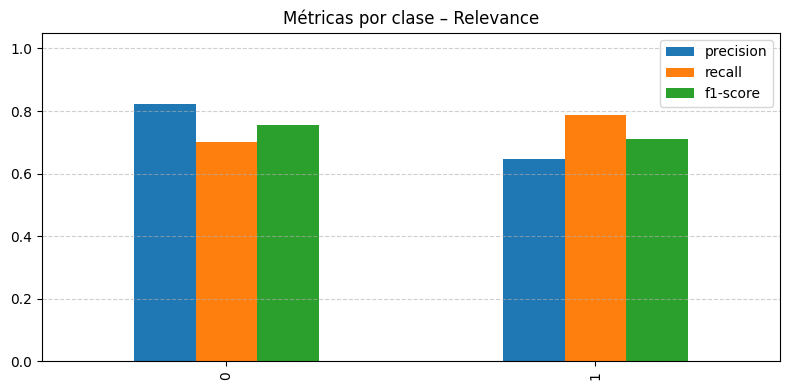

✅ Evaluación completa para 'Relevance'.
📈 Evaluando categoría: Interpretability


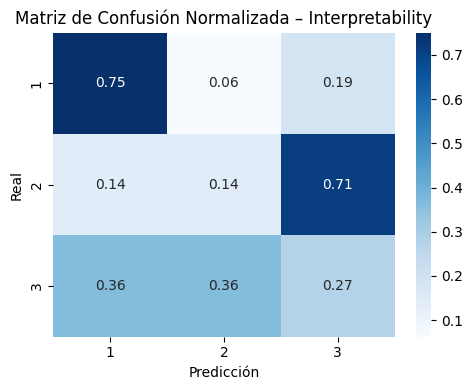

,precision,recall,f1-score
1,0.706,0.750,0.727
2,0.167,0.143,0.154
3,0.273,0.273,0.273


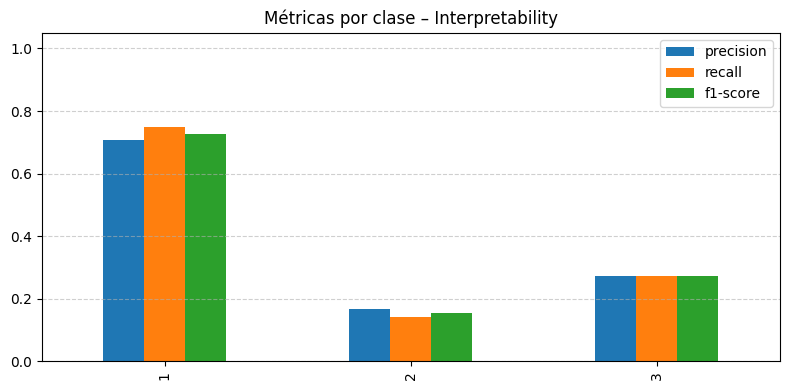

✅ Evaluación completa para 'Interpretability'.
📈 Evaluando categoría: Completeness


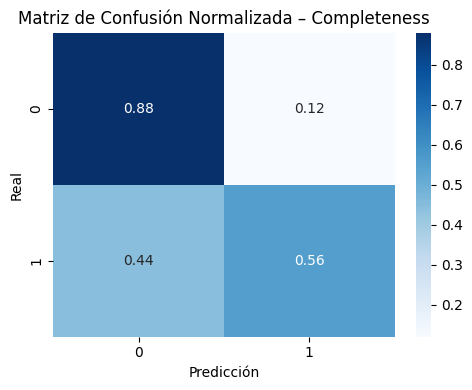

,precision,recall,f1-score
0,0.846,0.880,0.863
1,0.625,0.556,0.588


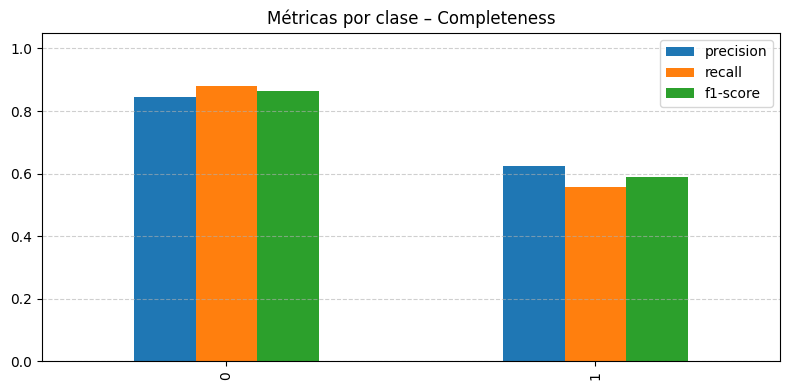

✅ Evaluación completa para 'Completeness'.
📈 Evaluando categoría: Differential Regime


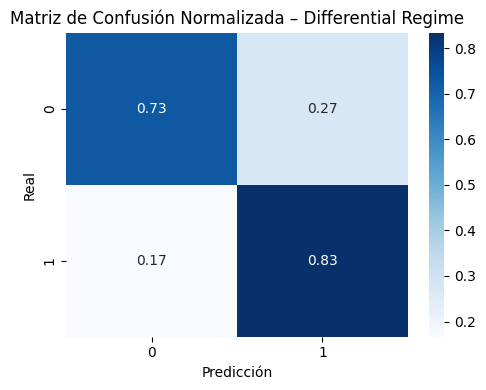

,precision,recall,f1-score
0,0.889,0.727,0.800
1,0.625,0.833,0.714


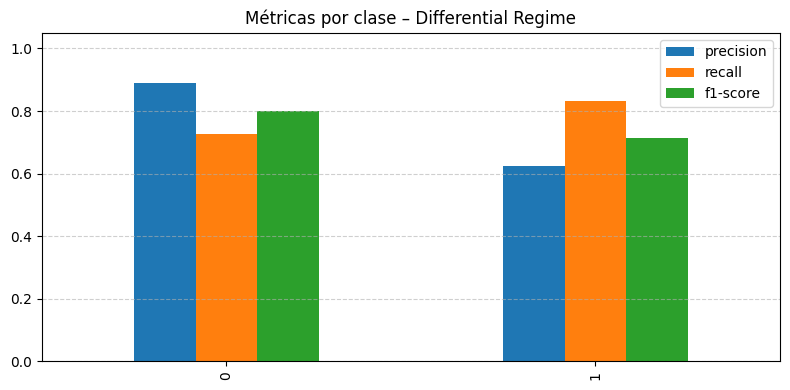

✅ Evaluación completa para 'Differential Regime'.
📈 Evaluando categoría: Discretionality


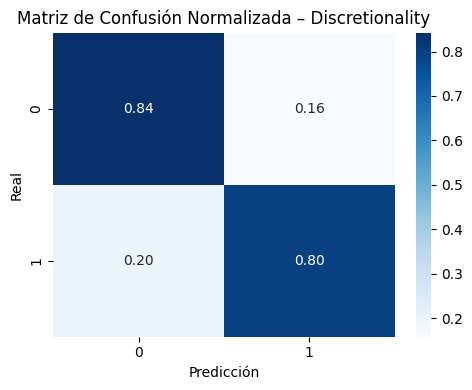

,precision,recall,f1-score
0,0.842,0.842,0.842
1,0.800,0.800,0.800


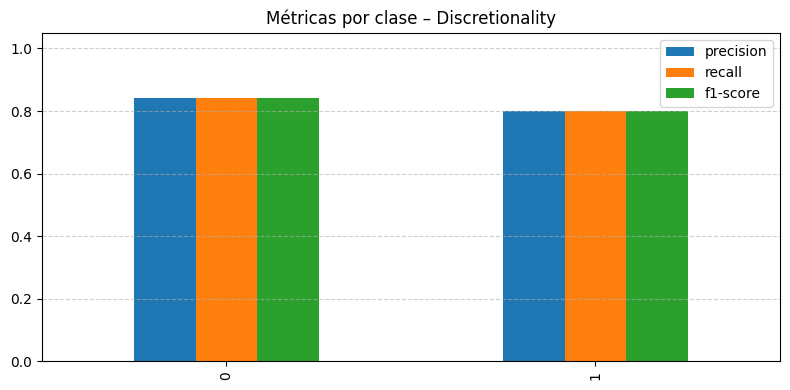

✅ Evaluación completa para 'Discretionality'.

📊 Comparativa entre modelos por categoría:


,Categoría,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
0,Relevance,0.735,0.733,0.737,0.735,0.743
1,Interpretability,0.471,0.385,0.462,0.382,0.389
2,Completeness,0.794,0.725,0.790,0.736,0.718
3,Differential Regime,0.765,0.757,0.770,0.757,0.780
4,Discretionality,0.824,0.821,0.824,0.821,0.821



⚠️ Se encontraron 48 errores de clasificación en total.


,Texto,Etiqueta real,Predicción,Categoría
0,decláranse utilidad pública terrenos áreas ind...,0,1,Relevance
1,adiciónese artículo estatuto tributario siguie...,1,0,Relevance
2,pacto subregional andino personas proyecten be...,0,1,Relevance
3,pacto andino empresas industriales instaladas ...,0,1,Relevance
4,adiciónese parágrafo modifícase parágrafo artí...,1,0,Relevance
5,régimen libertad cambiaria fin facilitar cumpl...,0,1,Relevance
6,venta divisas banco república registro capital...,0,1,Relevance
7,zona franca finalidad ser instrumento creación...,0,1,Relevance
8,valor manejo cargamentos zona franca industria...,1,0,Relevance
9,zona franca finalidad ser instrumento creación...,3,2,Interpretability



💾 Archivos guardados: 'resultados_metricas_por_categoria.xlsx' y 'errores_de_clasificacion.xlsx'


In [ ]:

# Resultados finales
resumen_global = []
errores_global = []

print("📊 Iniciando análisis de resultados...")

for res in resultados_modelo:
    cat = res['categoria']
    y_test = res['y_test']
    y_pred = res['y_pred']
    etiquetas = res['etiquetas']
    reporte = res['reporte']
    X_test = res['X_test']

    print("="*80)
    print(f"📈 Evaluando categoría: {cat}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred, labels=etiquetas, normalize='true')
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas)
    plt.title(f"Matriz de Confusión Normalizada – {cat}")
    plt.xlabel("Predicción"); plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    # Métricas por clase (verificamos nombres válidos)
    df_reporte = pd.DataFrame(reporte).T
    clases_reales = [str(c) for c in etiquetas if str(c) in df_reporte.index]

    df_clases = df_reporte.loc[clases_reales][['precision', 'recall', 'f1-score']].round(3)
    display(df_clases)

    # Gráfico de métricas
    df_clases.plot(kind='bar', figsize=(8,4))
    plt.title(f"Métricas por clase – {cat}")
    plt.ylim(0, 1.05)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Resumen global
    resumen_global.append({
        'Categoría': cat,
        'Accuracy': round(res['accuracy'], 3),
        'F1 Macro': round(df_reporte.loc['macro avg']['f1-score'], 3),
        'F1 Weighted': round(df_reporte.loc['weighted avg']['f1-score'], 3),
        'Precision Macro': round(df_reporte.loc['macro avg']['precision'], 3),
        'Recall Macro': round(df_reporte.loc['macro avg']['recall'], 3)
    })

    # Ejemplos mal clasificados
    errores_df = pd.DataFrame({
        'Texto': X_test,
        'Etiqueta real': y_test,
        'Predicción': y_pred
    })
    errores_df = errores_df[errores_df['Etiqueta real'] != errores_df['Predicción']]
    errores_df['Categoría'] = cat
    errores_global.append(errores_df)

    print(f"✅ Evaluación completa para '{cat}'.")

# Mostrar resumen comparativo
df_resultados = pd.DataFrame(resumen_global)
print("\n📊 Comparativa entre modelos por categoría:")
display(df_resultados)

# Concatenar y mostrar errores
df_errores = pd.concat(errores_global, ignore_index=True)
print(f"\n⚠️ Se encontraron {len(df_errores)} errores de clasificación en total.")
display(df_errores.head(10))

# Guardar archivos
df_resultados.to_excel("resultados_metricas_por_categoria.xlsx", index=False)
df_errores.to_excel("errores_de_clasificacion.xlsx", index=False)

print("\n💾 Archivos guardados: 'resultados_metricas_por_categoria.xlsx' y 'errores_de_clasificacion.xlsx'")


In [ ]:
def verificar_modelado(df, columna_categoria):
    print("="*90)
    print(f"🔍 Verificando modelado para la categoría: {columna_categoria}")

    # 1. Validar preprocesamiento
    vacíos = df['texto_limpio'].apply(lambda x: len(str(x).strip()) == 0).sum()
    if vacíos > 0:
        print(f"⚠️ Hay {vacíos} textos vacíos. Elimina o corrige antes de continuar.")
        return

    # 2. Validar distribución de clases
    clases = df[columna_categoria].dropna().value_counts()
    print("\n📊 Distribución de clases:")
    print(clases)

    if (clases < 5).any():
        print("⚠️ Hay clases con menos de 5 ejemplos. Esto puede dañar el entrenamiento.")

    # 3. Preparamos los datos
    datos = df[['texto_limpio', columna_categoria]].dropna()
    X = datos['texto_limpio']
    y = datos[columna_categoria]

    # 4. División train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 5. Entrenar modelo rápido con balanceo
    modelo = Pipeline([
        ('tfidf', TfidfVectorizer(min_df=3, ngram_range=(1,2))),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # 6. Métricas
    print("\n📈 Reporte de clasificación:")
    print(classification_report(y_test, y_pred, digits=3))

    # 7. Matriz de confusión
    etiquetas = sorted(y.unique())
    cm = confusion_matrix(y_test, y_pred, normalize='true', labels=etiquetas)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas)
    plt.title(f"Matriz de Confusión Normalizada – {columna_categoria}")
    plt.xlabel("Predicción"); plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    # 8. Errores
    errores_df = pd.DataFrame({
        'Texto': X_test,
        'Real': y_test,
        'Predicción': y_pred
    })
    errores_df = errores_df[errores_df['Real'] != errores_df['Predicción']]
    print(f"\n❌ Se encontraron {len(errores_df)} errores de predicción.")
    display(errores_df.head(5))

    # 9. Recomendaciones
    if (classification_report(y_test, y_pred, output_dict=True)['macro avg']['f1-score']) < 0.5:
        print("⚠️ El F1 macro es bajo. El modelo podría estar ignorando algunas clases.")
        print("🔧 Sugerencias: revisar desbalance o aumentar ejemplos.")
    else:
        print("✅ Todo parece estar funcionando razonablemente bien.")

verificar_modelado(df, 'Interpretability')

